# PROCESAMIENTO DE LOS DATOS 👾

In [ ]:
import numpy as np  #numerical calculations
import pandas as pd  #handling and analysis data
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler  #data preprocessing and feature scaling
from sklearn.model_selection import train_test_split  #data split
from sklearn.pipeline import make_pipeline, Pipeline  #building ML pipelines
from sklearn.compose import ColumnTransformer, make_column_selector  #column manipulation in pipelines
from sklearn.impute import SimpleImputer  #missing value imputation
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler  #one-Hot encoding and feature scaling
from feature_engine.selection import DropFeatures #drop feactures
from sklearn.tree import DecisionTreeClassifier  #tree classifier
from sklearn.metrics import confusion_matrix  #confusion matrix
from sklearn.model_selection import cross_validate #metrics cv
from sklearn.model_selection import cross_val_predict #prediction labels cv
import os #

In [ ]:
#load train data
train= pd.read_excel('Data/raw/train.xlsx')
train

,ID,Edad,Tipo_Trabajo,Estado_Civil,Educacion,mora,Vivienda,Consumo,Contacto,Mes,...,Campana,Dias_Ultima_Camp,No_Contactos,Resultado_Anterior,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,1,57,servicios,casado,bachillerato,NaN,no,no,telefono fijo,may,...,1,999,0,sin contacto,1.1,93994,-36.4,4857,5191,0
1,2,37,servicios,casado,bachillerato,no,si,no,telefono fijo,may,...,1,999,0,sin contacto,1.1,93994,-36.4,4857,5191,0
2,3,40,administrador negocio,casado,primaria,no,no,no,telefono fijo,may,...,1,999,0,sin contacto,1.1,93994,-36.4,4857,5191,0
3,4,56,servicios,casado,bachillerato,no,no,si,telefono fijo,may,...,1,999,0,sin contacto,1.1,93994,-36.4,4857,5191,0
4,7,25,servicios,single,bachillerato,no,si,no,telefono fijo,may,...,1,999,0,sin contacto,1.1,93994,-36.4,4857,5191,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23094,32963,29,desempleado,soltero,preescolar,no,si,no,celular,nov,...,1,9,1,satisfactorio,-1.1,94767,-50.8,1028,4964,0
23095,32964,46,empleado,casado,Estudiante Universitario,no,no,no,celular,nov,...,1,999,0,sin contacto,-1.1,94767,-50.8,1028,4964,0
23096,32965,56,pensionado,casado,pregrado,no,si,no,celular,nov,...,2,999,0,sin contacto,-1.1,94767,-50.8,1028,4964,0
23097,32966,44,tecnico,casado,Estudiante Universitario,no,no,no,celular,nov,...,1,999,0,sin contacto,-1.1,94767,-50.8,1028,4964,1


In [ ]:
#rename columns
train.rename(columns=lambda x: x.lower().replace(" ", "_"), inplace=True)

In [ ]:
#feactures
X= train.drop("y", axis=1)
#target
y= train["y"]
#data split
X_train, X_test, Y_train, Y_test= train_test_split(X, y, test_size=0.25, random_state=0, shuffle= True, stratify=None)

Pipeline

In [ ]:
#data pipeline
pipe = Pipeline([
    #Step 1: drop columns
    ('drop_columns', DropFeatures(['id'])),

    #Step 2:
    ('transformer', ColumnTransformer([
        # Step 2.1 categorial features
        ('cat', make_pipeline(
            SimpleImputer(strategy='most_frequent'), #impute missing values
            OneHotEncoder(handle_unknown='ignore') #one-hot encoding
        ),
         make_column_selector(dtype_include='object') #category columns
        ),

        #Step 2.2 numerical features
        ('num', make_pipeline(
            MinMaxScaler() #scale features
        ),
         make_column_selector(dtype_include='number') #numerical columns
        )
    ])),

    #Step 3: tree
    ('tree', DecisionTreeClassifier(max_depth=3))
])


In [ ]:
#pipe fitting
pipe.fit(X_train, Y_train)

Pipeline(steps=[('drop_columns', DropFeatures(features_to_drop=['id'])),
                ('transformer',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7f221b849430>),
                                                 ('num',
                                                  Pipeline(steps=[('minmaxscaler',
                                                                   MinMaxScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7f221b849c10>)])),
                ('tree', DecisionTreeClassifier(max_depth=3))])

In [ ]:
#No tree in pipeline
preprocessing_pipe= pipe[:-1]

In [ ]:
#data transform
transformed_data= preprocessing_pipe.fit_transform(train)

In [ ]:
#pipe features
features= pipe.named_steps['transformer'].get_feature_names_out()
pd.Series(features)


0     cat__tipo_trabajo_Vive de los arriendos
1     cat__tipo_trabajo_administrador negocio
2               cat__tipo_trabajo_ama de casa
3               cat__tipo_trabajo_desempleado
4                  cat__tipo_trabajo_empleado
5               cat__tipo_trabajo_emprendedor
6                cat__tipo_trabajo_estudiante
7                cat__tipo_trabajo_pensionado
8                 cat__tipo_trabajo_servicios
9                   cat__tipo_trabajo_tecnico
10       cat__tipo_trabajo_vendedor ambulante
11                   cat__estado_civil_casado
12                 cat__estado_civil_divorced
13               cat__estado_civil_divorciado
14                   cat__estado_civil_single
15                  cat__estado_civil_soltero
16    cat__educacion_Estudiante Universitario
17                     cat__educacion_Ninguno
18                cat__educacion_bachillerato
19     cat__educacion_bachillerato incompleto
20                  cat__educacion_preescolar
21                    cat__educaci

In [ ]:
#transformed dataframe
train_transformed= pd.DataFrame(transformed_data, columns=features)
train_transformed

,cat__tipo_trabajo_Vive de los arriendos,cat__tipo_trabajo_administrador negocio,cat__tipo_trabajo_ama de casa,cat__tipo_trabajo_desempleado,cat__tipo_trabajo_empleado,cat__tipo_trabajo_emprendedor,cat__tipo_trabajo_estudiante,cat__tipo_trabajo_pensionado,cat__tipo_trabajo_servicios,cat__tipo_trabajo_tecnico,...,num__edad,num__campana,num__dias_ultima_camp,num__no_contactos,num__emp_var_rate,num__cons_price_idx,num__cons_conf_idx,num__euribor3m,num__nr_employed,num__y
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.506494,0.00000,1.000000,0.000000,0.937500,0.991835,0.60251,0.962728,0.859848,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.246753,0.00000,1.000000,0.000000,0.937500,0.991835,0.60251,0.962728,0.859848,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.285714,0.00000,1.000000,0.000000,0.937500,0.991835,0.60251,0.962728,0.859848,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.493506,0.00000,1.000000,0.000000,0.937500,0.991835,0.60251,0.962728,0.859848,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.090909,0.00000,1.000000,0.000000,0.937500,0.991835,0.60251,0.962728,0.859848,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23094,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.142857,0.00000,0.009009,0.166667,0.479167,1.000000,0.00000,0.203608,0.000000,0.0
23095,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.363636,0.00000,1.000000,0.000000,0.479167,1.000000,0.00000,0.203608,0.000000,0.0
23096,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.493506,0.02439,1.000000,0.000000,0.479167,1.000000,0.00000,0.203608,0.000000,0.0
23097,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.337662,0.00000,1.000000,0.000000,0.479167,1.000000,0.00000,0.203608,0.000000,1.0


Tree

In [ ]:
#tree
tree= pipe.named_steps['tree']
#tree= pipe['tree'] -> otra forma de acceder a 'Tree'

In [ ]:
#root node
root_node= tree.tree_
root_index= 0
num_samples_root= root_node.n_node_samples[root_index]
majority_class= tree.classes_[root_node.value[root_index].argmax()]
feature_index= root_node.feature[root_index]
threshold= root_node.threshold[root_index]

print("Número de muestras:", num_samples_root)
print("Clase mayoritaria:", majority_class)
print("Índice de característica:", feature_index)
print("Umbral utilizado:", threshold)

Número de muestras: 17324
Clase mayoritaria: 0
Índice de característica: 57
Umbral utilizado: 0.467803031206131


In [ ]:
#important features
data= {'Features': np.delete(features, -1), 'Importances': tree.feature_importances_}
features_importances= pd.DataFrame(data).sort_values(by='Importances', ascending=False)
features_importances.loc[features_importances['Importances']>0]

,Features,Importances
57,num__nr_employed,0.737678
47,cat__resultado_anterior_satisfactorio,0.141977
55,num__cons_conf_idx,0.071049
54,num__cons_price_idx,0.024520
39,cat__mes_oct,0.014987
36,cat__mes_mar,0.009788


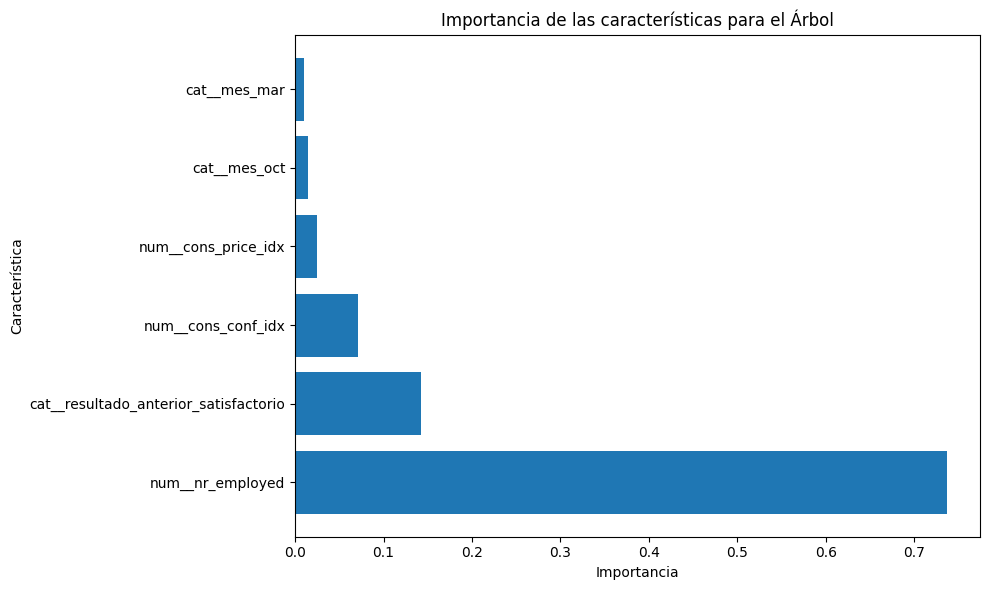

In [ ]:
#feature importances plot
features_plot= features_importances.loc[features_importances['Importances']>0]
plt.figure(figsize=(10, 6))
plt.barh(features_plot['Features'], features_plot['Importances'])
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.title('Importancia de las características para el Árbol')
plt.tight_layout()
plt.show()

Tree Plot 

In [ ]:
#tree plot libraries
from sklearn.tree import export_graphviz
import graphviz


In [ ]:
#tree .dot
export_graphviz(tree, 
                out_file=os.path.join('Data/external', 'tree.dot'), 
                class_names= [str(c) for c in tree.classes_],
                feature_names= np.delete(features, -1),
                impurity=True, 
                filled=True)

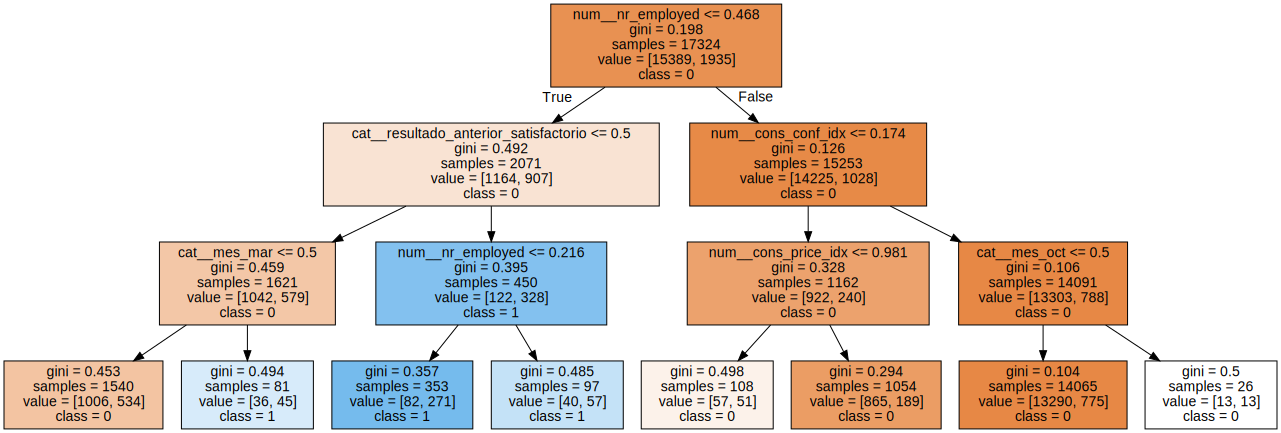

In [ ]:
#open .dot file
with open(os.path.join('Data/external', 'tree.dot')) as f:dot_graph = f.read()
display(graphviz.Source(dot_graph))

Predictions

In [ ]:
#feactures
X= train_transformed.drop("num__y", axis=1)
#target
y= train_transformed["num__y"]
#data split
X_train, X_test, Y_train, Y_test= train_test_split(X, y, test_size=0.25, random_state=0, shuffle= True, stratify=None) 

In [ ]:
from sklearn.metrics import recall_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
scoring= ['roc_auc', 'accuracy', 'f1', 'precision', 'recall']

**cross_validate**: realiza validación cruzada y obtiene métricas de evaluación para cada pliegue
**cross_val_predict**: obtiene las predicciones del modelo durante la validación cruzada, que luego se pueden usar para calcular la matriz de confusión

In [ ]:
#cross_val_predict: prediction labels (train) cv
y_pred_cv= cross_val_predict(tree, X_train, Y_train, cv=10)
y_pred_cv

array([0., 0., 0., ..., 0., 0., 0.])

Rendimiento del árbol en el conjunto de entrenamiento

In [ ]:
#confusion matrix
'''[[TP, FP]
    [FN, TN]]'''

confusion_matrix(Y_train, y_pred_cv)

array([[15237,   152],
       [ 1588,   347]])

In [ ]:
#cross_validate: metrics cv
cv_scores= cross_validate(tree, X_train, Y_train, cv=10, scoring=scoring)
cv_scores

{'fit_time': array([0.0737834 , 0.05361867, 0.078192  , 0.06564736, 0.06215143,
        0.08480763, 0.11986327, 0.06276035, 0.04216599, 0.03032231]),
 'score_time': array([0.03399277, 0.02394271, 0.02536345, 0.01324558, 0.04394555,
        0.03932905, 0.03412533, 0.02061844, 0.01416636, 0.01372528]),
 'test_roc_auc': array([0.77678805, 0.73430498, 0.76933073, 0.70387452, 0.71380548,
        0.71646854, 0.76615089, 0.75475462, 0.78496231, 0.73188   ]),
 'test_accuracy': array([0.89959608, 0.90248125, 0.89613387, 0.8932487 , 0.90011547,
        0.90588915, 0.89722864, 0.90011547, 0.89896074, 0.90184758]),
 'test_f1': array([0.275     , 0.27467811, 0.25619835, 0.2687747 , 0.27615063,
        0.31223629, 0.27642276, 0.31075697, 0.29149798, 0.30894309]),
 'test_precision': array([0.7173913 , 0.82051282, 0.64583333, 0.57627119, 0.7173913 ,
        0.84090909, 0.64150943, 0.67241379, 0.66666667, 0.73076923]),
 'test_recall': array([0.17010309, 0.16494845, 0.15979381, 0.17525773, 0.17098446,
 

In [ ]:
#mean and std recall score
mean_score= round(np.mean(cv_scores['test_recall']),2)
std_score= round(np.std(cv_scores['test_recall']),2)

In [ ]:
print(f'Recall:\n{mean_score}\n{std_score}')

Recall:
0.18
0.01


In [ ]:
#mean and std f1 score
mean_score= round(np.mean(cv_scores['test_f1']),2)
std_score= round(np.std(cv_scores['test_f1']),2)

In [ ]:
print(f'F1 score:\n{mean_score}\n{std_score}')

F1 score:
0.29
0.02


Rendimiento del árbol en el conjunto de prueba

In [ ]:
#cross_val_predict: prediction labels (test) cv
y_pred_cv= cross_val_predict(tree, X_test, Y_test, cv=10)
y_pred_cv

array([0., 0., 0., ..., 0., 0., 0.])

In [ ]:
#confusion matrix
'''[[TP, FP]
    [FN, TN]]'''

confusion_matrix(Y_test, y_pred_cv)

array([[5068,   52],
       [ 535,  120]])

In [ ]:
print("Recall: %s \n" %round(recall_score(Y_test, y_pred_cv),2))
print("F1 Score: %s \n" %round(f1_score(Y_test, y_pred_cv, average="binary"),2))
print("Accuracy: %s \n" %round(accuracy_score(Y_test, y_pred_cv),2))
print("Roc: %s \n" %round(roc_auc_score(Y_test, y_pred_cv),2))
print("Precision: %s \n" %round(precision_score(Y_test, y_pred_cv),2))

Recall: 0.18 

F1 Score: 0.29 

Accuracy: 0.9 

Roc: 0.59 

Precision: 0.7 



**Guardar DataFrame en formato .csv**

In [ ]:
#train_transformed.to_csv('train_processed.csv', index=False)
train_transformed.to_csv(os.path.join('Data/processed', 'train_processed.csv'), index=False)

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=ed4e5f13-3af9-48d3-90dc-acc295659d32' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>